### Zero Curve Rate Interpolation

Extract zero rate curve using discrete values at different times

Interpolation used are Linear and Cubin spline

| Time (month) | Interest rate (%) |
| -----------: | ----------------: |
|            0 |               0.5 |
|            2 |              0.65 |
|            6 |              0.85 |
|           12 |              1.05 |
|           20 |              1.20 |


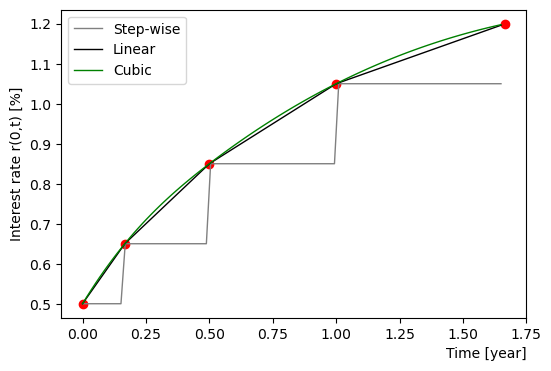

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from bisect import bisect_right
from scipy.interpolate import CubicSpline

data = {'t': [0, 1/6, 1/2, 1, 20/12],
        'r': [0.50, 0.65, 0.85, 1.05, 1.20]}
zero_rates = pd.DataFrame(data=data, columns=['t', 'r'])

def step_wise_interpolation(times, rates, t):
    # Generate step-wise interpolation between given boundaries
    if t < times[0] or t > times[-1]:
        raise Exception(f'Warning: Time ({t}) outside of interpolation range [{times[0]} - {times[-1]}]')
    # Locate index of insertion with binary search (bisect)
    idx = bisect_right(times, t) - 1
    # Use rate located at insertion point
    return rates[idx]


def linear_interpolation(times, rates, t):
    # Generate linear interpolation between given boundaries
    if t < times[0] or t > times[-1]:
        raise Exception(f'Warning: Time ({t}) outside of interpolation range [{times[0]} - {times[-1]}]')
    # Locate t1 and t2 that contain the time t using binary search
    idx = bisect_right(times, t)
    idx1, idx2 = idx - 1, idx
    # Linear interpolation
    return rates[idx1] + (t - times[idx1])*(rates[idx2] - rates[idx1])/(times[idx2] - times[idx1])


def cubic_interpolation(times, rates, t):
    # Genearte cubic spline interpolation with given values
    if t < times[0] or t > times[-1]:
        raise Exception(f'Warning: Time ({t}) outside of interpolation range [{times[0]} - {times[-1]}]')
    
    interp_func = CubicSpline(times, rates)
    return interp_func(t)


times = np.linspace(zero_rates['t'].to_numpy()[0], zero_rates['t'].to_numpy()[-1], 100)[:-1]
rates_step = [step_wise_interpolation(zero_rates['t'].to_numpy(), zero_rates['r'].to_numpy(), t) for t in times]
rates_lin  = [linear_interpolation(zero_rates['t'].to_numpy(), zero_rates['r'].to_numpy(), t) for t in times]
rates_cub  = [cubic_interpolation(zero_rates['t'].to_numpy(), zero_rates['r'].to_numpy(), t) for t in times]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(times, rates_step, color='grey', lw=1, label='Step-wise')
ax.plot(times, rates_lin,  color='black', lw=1, label='Linear')
ax.plot(times, rates_cub, color='green', lw=1, label='Cubic')
ax.scatter(zero_rates['t'].to_numpy(), zero_rates['r'].to_numpy(), color='red')
ax.set_xlabel('Time [year]', loc='right')
ax.set_ylabel('Interest rate r(0,t) [%]')
ax.legend()
plt.show()
